# Denoising Diffusion Probabilistic Models (DDPM)

**Goal**: Sample from a data distribution $p_\text{data}(x)$ which is known from examples (data points, images).

**Idea**: Define a process to transform samples from $p_\text{data}$ to samples from a distribution we can sample from, $\mathcal{N}(\mathbf{0}, \mathbf{I})$. Learn how to reverse it, and generate by starting from sampled noise.


## The Forward Process

We start with a data sample $x_0$, and in each step, we add a small amount of Gaussian noise $\epsilon\sim\mathcal{N}(0,I)$
$$x_t = \sqrt{1-\beta_t}\,x_{t-1} + \sqrt{\beta_t}\,\epsilon,$$
The scalars $0 < \beta_1 \leq \cdots \leq \beta_T < 1$ form the **noise schedule** (it can be learned, engineered or theory-motivated, but a simple choice is just linear increase over a fixed number of steps). The scaling factors keep the variance preserved.

This defines a discrete-time Markov chain $\mathbf{x}_0, \mathbf{x}_1, \ldots, \mathbf{x}_T$ where $\mathbf{x}_0 \sim p_\text{data}$
$$q(\mathbf{x}_t \mid \mathbf{x}_{t-1}) = \mathcal{N}\!\left(\mathbf{x}_t;\;\sqrt{1-\beta_t}\,\mathbf{x}_{t-1},\;\beta_t\mathbf{I}\right)$$

**Physical analogy:** a data sample is a particle in high-d space that starts moving randomly. A structured distribution of data points would dissolve into an unstructured cloud eventually.

### Closed-Form Forward Kernel
A small trick to sample data after t steps: the sum of Gaussian steps is also Gaussian, and we only need to adjust the variance.
Define $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$. Then:

$$q(\mathbf{x}_t \mid \mathbf{x}_0) = \mathcal{N}\!\left(\mathbf{x}_t;\;\sqrt{\bar{\alpha}_t}\,\mathbf{x}_0,\;(1-\bar{\alpha}_t)\mathbf{I}\right)$$

Equivalently: $\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\varepsilon$ where $\varepsilon \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$.

This means we can sample $\mathbf{x}_t$ for any $t$ in **one step**, without simulating the whole chain.

## The Reverse Process

The reverse process $p_\theta(\mathbf{x}_{t-1} \mid \mathbf{x}_t)$ is what we want to learn (by optimizing parameters $\theta$). Because each forward step adds only a small amount of noise, the reverse step is **also approximately Gaussian**:

$$p_\theta(\mathbf{x}_{t-1} \mid \mathbf{x}_t) = \mathcal{N}\!\left(\mathbf{x}_{t-1};\;\mu_\theta(\mathbf{x}_t, t),\;\beta_t\mathbf{I}\right)$$

The expected sample position at the reversed step, $\mu_\theta$, could be the output of a neural network. It is a vector of the data dimension (so the diffusive noise varies across coordinates, as well as across realizations). Note that the noise variance here is $\beta$ and doesn't have to be learned.

## The Training Objective

Instead of predicting $\mu_{\theta}$, we can equivalently (empirically this works well) train our model to **predict the noise $\varepsilon$** that was added. With $x_t=\sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon$:

$$\boxed{\mathcal{L} = \mathbb{E}_{t, \mathbf{x}_0, \varepsilon}\!\left[\left\|\varepsilon - \varepsilon_\theta\!\left(x_t,\;t\right)\right\|^2\right]}$$

For a random timestep $t$: add noise $\varepsilon$ to get $\mathbf{x}_t$, and ask the network to predict $\varepsilon$ based on $t$ and $x_t$.

## The DDPM Sampling algorithm

At each reverse step, predict the noise with the network, use it to reverse the current data point to the new $\mu_{\theta}$, and **add fresh noise on top**.

We can calculate $\mu_{\theta}$ from the predicted noise $\hat{\boldsymbol{\varepsilon}} = \varepsilon_\theta(\mathbf{x}_t, t)$:

$$\mu_{\theta} = \frac{1}{\sqrt{\alpha_t}}\!\left(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\hat{\boldsymbol{\varepsilon}}\right)$$

The scaling factors (depending on $\alpha$ and $\beta$) are needed because of the rescaling during the forward process.

1. Sample $\mathbf{x}_T \sim \mathcal{N}(\mathbf{0},\mathbf{I})$.
2. For $t = T, T{-}1, \ldots, 1$: evaluate $\hat{\boldsymbol{\varepsilon}} = \varepsilon_\theta(\mathbf{x}_t, t)$, compute $\mu_{\theta}$ from the formula above, and step to $\mathbf{x}_{t-1} = \mu_{\theta} + \sqrt{\beta_t}\,\mathbf{z}$ with $\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$.
3. At $t=1$: skip the stochastic term and set $x_0 = \mu_{\theta}$.


## Why does this work?

(The mathematics that was too much work to go through)

**What is the foundation of the training objective?**
We glossed over quite a bit of reasoning here. Intuitively: learn the noise in each step, then it can be used to reverse the process.
The derivation is in broad terms: Try to maximise the likelihood of the data $\log p_\theta(\mathbf{x}_0)$ given the multi-step process model. This can be made tractable, by using the ELBO as approximation, as well as analytical properties of the normal distribution and results in the MSE objective for predicting the mean (or noise) in each step. It was also found that some prefactors involving $\beta$ can be set to one (for a simplified noise schedule with good results).


**Why is the reverse process Gaussian?**
Because each forward step only adds a Gaussian perturbation ($\beta_t \ll 1$), the kernel $q(\mathbf{x}_t\mid\mathbf{x}_{t-1})$ is a narrow Gaussian in $\mathbf{x}_{t-1}$. Inverting with Bayes' rule, $q(\mathbf{x}_{t-1}\mid\mathbf{x}_t) \propto q(\mathbf{x}_t\mid\mathbf{x}_{t-1})\,q(\mathbf{x}_{t-1})$ (as a function of $x_{t-1}$, with fixed $x_t$). By construction, $q(x_{t-1})$ is more like the complete data distribution, with a much larger variance $\mathcal{O}(1)$ so we can neglect its contribution.

**Why is this stable when using small enough time steps?**
In each reverse step, we make a small error depending on $\beta=1/T$ for $T$ steps. The error can be measured by the KL divergence betwen the data distribution at that step, and the distribution resulting from the stepwise approximate reverse process. After multiple steps, these errors compound, leading to a KL divergence between the sampled data distribution and the real distribution after the end of the process. In each step, the error is of the order $\mathcal{O}(\beta^2)$, and the error compounds additively to $\approx T\cdot 1/T^2=1/T$. Therefore, the sampled data distribution is a better approximation for finer steps.

**Why do we need to add noise to the reverse steps?**
Recall that the forward model is designed as a stochastic Markov step with non-zero variance, and the model was fit to reproduce it. Therefore, the backward process also needs to be a stochastic process. Without stochasticity, sampled data points can collapse to high probability modes. The stochasticity also helps to avoid the compounding of errors from noise prediction.


## Context and References
- DDPM can also be derived as a hierarchical VAE with T layers, a fixed encoder, and tied/shared decoder weights across steps.
- The DDPM / diffusion point of view of can be shown to be basically the same idea as score-based models (formulated with stochastic gradient langevin dynamics) using discretizations of stochastic differential equations.
- A bottleneck in these algorithms is the generation procedure involving many steps, and new methods (like flow matching) have been developed to address this.

### References
- Jascha Sohl-Dickstein et al. [Deep Unsupervised Learning using Nonequilibrium Thermodynamics](https://arxiv.org/abs/1503.03585) — the statistical physics derived framework to use diffusion for generative modeling.
- Ho et al. (2020) — [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239) — the DDPM paper, coming from a different direction to the same idea, with some improvements, and demonstration of larger scale image generation.
- Lilian Weng (2021) — [What are Diffusion Models?](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/) — blog post including derivations; thorough and well-illustrated

In [1]:
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import flax.linen as nn
import optax
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" # suppress warnings

key = random.PRNGKey(0)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
print('JAX:', jax.__version__, '| devices:', jax.devices())

JAX: 0.9.2 | devices: [CudaDevice(id=0)]


## Toy Data

A simple but not trivial dataset: can be visualized in 2d, concentrates data on a low dimensional manifold, and is clustered.

x shape: (2000, 2)


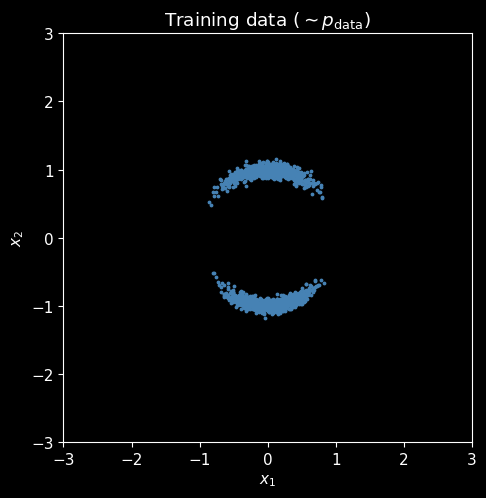

In [2]:
def sample_data(key, n=2000, sigma_z=0.3, sigma_obs=0.05):
    """Sample n points from the circular two-cluster dataset.

    Latent z ~ equal mixture of N(pi/2, sigma_z) and N(3pi/2, sigma_z), wrapped to [0, 2pi].
    Observed x = (cos z, sin z) + N(0, sigma_obs^2 I).

    Returns:
        x: (n, 2) observed positions
        z: (n,) true latent angles in [0, 2pi]
    """
    k1, k2, k3 = random.split(key, 3)
    components = random.bernoulli(k1, p=0.5, shape=(n,))
    centers = jnp.where(components, 3 * jnp.pi / 2, jnp.pi / 2)
    z_raw = centers + sigma_z * random.normal(k2, shape=(n,))
    z = z_raw % (2 * jnp.pi)
    x_clean = jnp.stack([jnp.cos(z), jnp.sin(z)], axis=-1)
    x = x_clean + sigma_obs * random.normal(k3, shape=(n, 2))
    return x, z

key = random.PRNGKey(0)
sigma_z = 0.3
x_data, _ = sample_data(key, sigma_z=sigma_z)
num_samples, num_d = x_data.shape
x_lim = (-3, 3)
y_lim = (-3, 3)
print(f"x shape: {x_data.shape}")

fig, ax = plt.subplots(figsize=(5, 6))
ax.scatter(x_data[:, 0], x_data[:, 1], s=3, c='steelblue')
ax.set_title('Training data ($ \\sim p_{\\text{data}}$)')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_xlim(*x_lim)
ax.set_ylim(*y_lim)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


# Visualize the Forward Diffusion Process

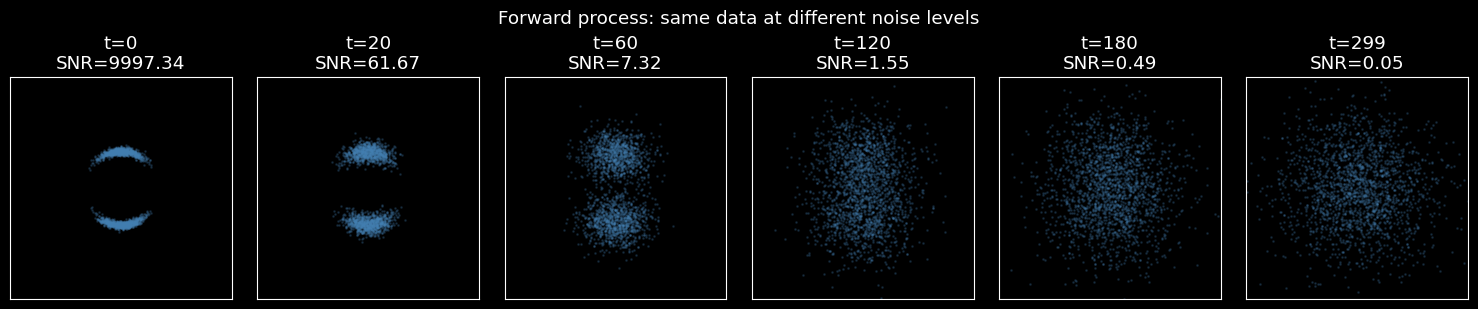

In [3]:
T = 300
betas      = jnp.linspace(1e-4, 0.02, T)   # linear noise schedule
alphas     = 1.0 - betas
alpha_bars = jnp.cumprod(alphas)            # signal scaling: abar_t = prod alpha_s

def q_sample(x0, t, eps):
    '''
    The trick to use one noise realization to produce a sample at time t.
    Closed-form forward sample: x_t = sqrt(abar_t)*x0 + sqrt(1-abar_t)*eps.
    '''
    ab = alpha_bars[t]
    return jnp.sqrt(ab) * x0 + jnp.sqrt(1 - ab) * eps

# Use the SAME noise draws for all t to show the trajectory of specific points
key, sk = random.split(key)
eps_fixed = random.normal(sk, x_data.shape)

show_t = [0, 20, 60, 120, 180, 299]
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for ax, t in zip(axes, show_t):
    xt = q_sample(x_data, t, eps_fixed)
    snr = float(alpha_bars[t] / (1 - alpha_bars[t])) # signal to noise ratio
    ax.scatter(xt[:, 0], xt[:, 1], s=1, alpha=0.2, c='steelblue')
    ax.set_title(f't={t}\nSNR={snr:.2f}')
    ax.set_xlim(*x_lim); ax.set_ylim(*y_lim)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Forward process: same data at different noise levels', y=1.02)
plt.tight_layout(); plt.show()

## Model Training: Learn to Predict Noise

**Algorithm for one training step:**
1. Sample $\mathbf{x}_0$ from the data, pick a random $t \in \{1,\ldots,T\}$
2. Sample noise $\boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0},\mathbf{I})$ and compute $\mathbf{x}_t$ using the closed form
3. Pass $\mathbf{x}_t$ and $t$ to the network; penalise the MSE between the prediction and $\boldsymbol{\varepsilon}$

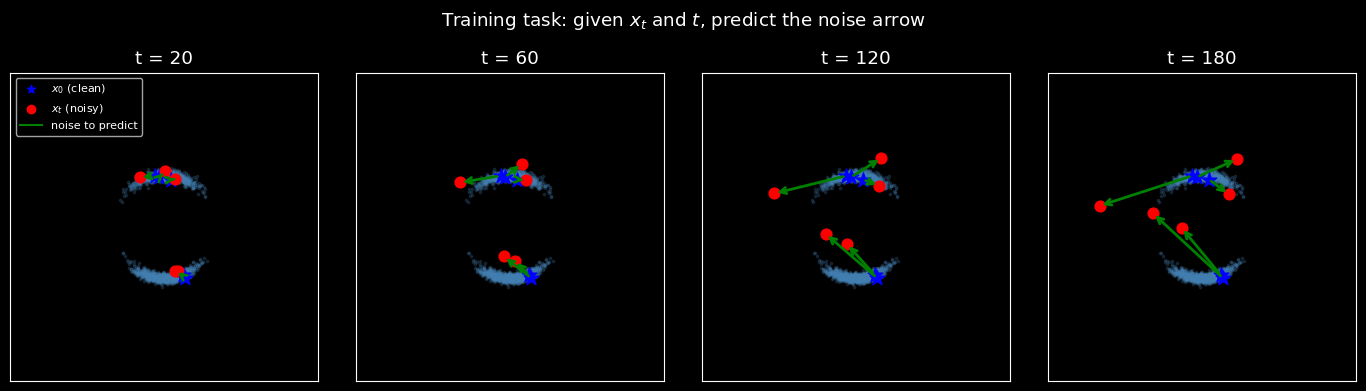

In [4]:
# Visualise the noise-prediction task.
# Given the red dot (x_t) and t, the network must predict the green arrow (the noise that was added).
key, sk1, sk2 = random.split(key, 3)

# Pick random points from the data distribution
n_show = 5
idx = random.choice(sk1, x_data.shape[0], shape=(n_show,), replace=False)
x0_show = x_data[idx]
eps_show = random.normal(sk2, x0_show.shape)  # one noise draw per point, shared across t

t_show = [20, 60, 120, 180]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, t in zip(axes, t_show):
    ax.scatter(x_data[:, 0], x_data[:, 1], s=3, alpha=0.2, c='steelblue')
    for p in range(n_show):
        xt_p = q_sample(x0_show[p], t, eps_show[p])
        ax.scatter(*x0_show[p], s=120, c='blue', marker='*', zorder=3)
        ax.scatter(*xt_p,       s=60,  c='red',  marker='o', zorder=3)
        ax.annotate('', xy=xt_p, xytext=x0_show[p],
                    arrowprops=dict(arrowstyle='->', color='green', lw=2))
    ax.set_title(f't = {t}')
    ax.set_xlim(*x_lim); ax.set_ylim(*y_lim)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

axes[0].scatter([], [], c='blue',  marker='*', label='$x_0$ (clean)')
axes[0].scatter([], [], c='red',   marker='o', label='$x_t$ (noisy)')
axes[0].plot(   [], [], c='green',             label='noise to predict')
axes[0].legend(fontsize=8, loc='upper left')

plt.suptitle('Training task: given $x_t$ and $t$, predict the noise arrow', y=1.02)
plt.tight_layout(); plt.show()

## The Noise-Prediction Network

We parameterise $\boldsymbol{\varepsilon}_\theta(\mathbf{x}_t, t)$ as a neural network that takes the noisy sample and the timestep as inputs and outputs the predicted noise.

### Time conditioning

At $t = 10$, only a small correction is needed. At $t = 200$, the sample almost looks like noise. Encoding $t$ explicitly provides critical information (even with knowing $t$, the task is ambiguous).

We use **sinusoidal (Fourier) embeddings** with a range of log-spaced frequencies - similar to positional encodings in transformers.

$$\text{emb}_{2i}(t) = \sin\!\left(\frac{t}{10000^{2i/d}}\right), \qquad \text{emb}_{2i+1}(t) = \cos\!\left(\frac{t}{10000^{2i/d}}\right)$$

This encoding provides information for fine differences for small ts as well as larger differences for large ts in separate features for the network to use.

In terms or architecture a small MLP works for our 2D toy problem.

In [5]:
class TimeEmbed(nn.Module):
    '''Sinusoidal time embedding, followed by a learned linear projection.'''
    dim: int = 32

    @nn.compact
    def __call__(self, t_int):
        t = t_int.astype(jnp.float32)
        half = self.dim // 2
        # Geometric sequence of frequencies
        freqs = jnp.exp(-jnp.arange(half) * jnp.log(10000.0) / (half - 1))
        args  = t[:, None] * freqs[None, :]          # (batch, half)
        emb   = jnp.concatenate([jnp.sin(args), jnp.cos(args)], axis=-1)
        return nn.Dense(self.dim)(emb)               # learnable projection


class ScoreNet(nn.Module):
    '''Predict noise eps_theta(x_t, t): takes (batch,2) + (batch,) int -> (batch,2).'''
    hidden: int = 128

    @nn.compact
    def __call__(self, x, t):
        emb = TimeEmbed()(t)                         # (batch, 32)
        h   = jnp.concatenate([x, emb], axis=-1)    # (batch, 34)
        h   = nn.Dense(self.hidden)(h)
        h   = nn.silu(h)
        h   = nn.Dense(self.hidden)(h)
        h   = nn.silu(h)
        return nn.Dense(2)(h)                        # predict 2D noise


model = ScoreNet()
key, sk = random.split(key)
params = model.init(sk, jnp.zeros((1, 2)), jnp.zeros((1,), jnp.int32))
n_p = sum(leaf.size for leaf in jax.tree_util.tree_leaves(params))
print(f'Network parameters: {n_p:,}')

Network parameters: 22,306


In [6]:
optimizer = optax.adam(3e-4)
opt_state = optimizer.init(params)

@jit
def train_step(params, opt_state, x0, key):
    k1, k2 = random.split(key)
    n     = x0.shape[0]
    t     = random.randint(k1, (n,), 0, T)           # random timestep per sample
    noise = random.normal(k2, x0.shape)              # noise to add AND predict

    def loss_fn(params):
        ab = alpha_bars[t][:, None]
        xt   = jnp.sqrt(ab) * x0 + jnp.sqrt(1 - ab) * noise   # closed-form x_t
        pred = model.apply(params, xt, t)
        return jnp.mean((pred - noise) ** 2)         # MSE on noise

    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt = optimizer.update(grads, opt_state)
    return optax.apply_updates(params, updates), new_opt, loss


n_epochs, batch_size = 5000, 256
losses = []

for epoch in range(n_epochs):
    key, sk1, sk2 = random.split(key, 3)
    idx   = random.randint(sk1, (batch_size,), 0, len(x_data))
    batch = x_data[idx]
    params, opt_state, loss_val = train_step(params, opt_state, batch, sk2)
    losses.append(float(loss_val))
    if epoch % 500 == 0:
        print(f'Epoch {epoch:4d}  loss = {loss_val:.4f}')

Epoch    0  loss = 1.0397
Epoch  500  loss = 0.3546
Epoch 1000  loss = 0.3491
Epoch 1500  loss = 0.4028
Epoch 2000  loss = 0.3813
Epoch 2500  loss = 0.2188
Epoch 3000  loss = 0.2653
Epoch 3500  loss = 0.2832
Epoch 4000  loss = 0.2319
Epoch 4500  loss = 0.2389


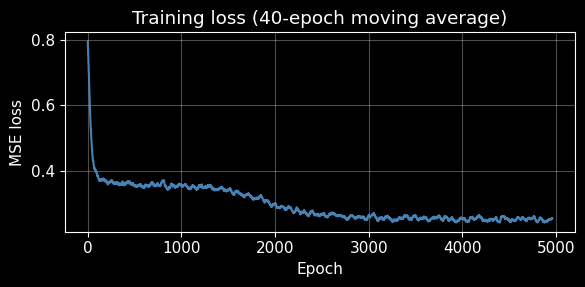

In [7]:
w = 40
smoothed = np.convolve(losses, np.ones(w) / w, mode='valid')
plt.figure(figsize=(6, 3))
plt.plot(smoothed, lw=1.5, c='steelblue')
plt.xlabel('Epoch'); plt.ylabel('MSE loss')
plt.title(f'Training loss ({w}-epoch moving average)')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Sampling by Running the Reverse Process

With a trained model in place, we can generate samples by starting from pure Gaussian noise and iteratively denoising.

1. Sample $\mathbf{x}_T \sim \mathcal{N}(\mathbf{0},\mathbf{I})$
2. For $t = T, T{-}1, \ldots, 1$: compute $\mu_{\theta}$ using predicted noise,
$$\mu_{\theta} = \frac{1}{\sqrt{\alpha_t}}\!\left(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\hat{\boldsymbol{\varepsilon}}\right)$$
 then the denoised next step
   $$\mathbf{x}_{t-1} = \mu_{\theta} + \sqrt{\beta_t}\,\mathbf{z}, \quad \mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$$
3. At $t=1$: set $\mathbf{x}_0 = \mu_{\theta}$ (no stochastic noise at the final step)



In [8]:
def ddpm_sample(params, n_samples, key, save_every=50):
    '''Run full reverse chain x_T -> x_0, optionally saving intermediate states.'''
    key, sk = random.split(key)
    x = random.normal(sk, (n_samples, 2))       # start from pure noise
    trajectory = {T: np.array(x)}

    for t in range(T - 1, -1, -1):
        key, sk       = random.split(key)
        t_batch       = jnp.full((n_samples,), t, dtype=jnp.int32)
        eps_hat       = model.apply(params, x, t_batch)     # predicted noise

        alpha_t  = alphas[t]
        ab_t     = alpha_bars[t]
        beta_t   = betas[t]

        # Compute reverse mean using predicted noise
        mean = (x - beta_t / jnp.sqrt(1 - ab_t) * eps_hat) / jnp.sqrt(alpha_t)

        # Add stochastic noise (skip at final step to avoid extra variance)
        z = random.normal(sk, x.shape)
        x = mean + (jnp.sqrt(beta_t) * z if t > 0 else 0.0)

        if t % save_every == 0:
            trajectory[t] = np.array(x)

    return x, trajectory

print('Running reverse diffusion...')
key, sk = random.split(key)
samples, traj = ddpm_sample(params, 2000, sk)
print('Done.')

Running reverse diffusion...
Done.


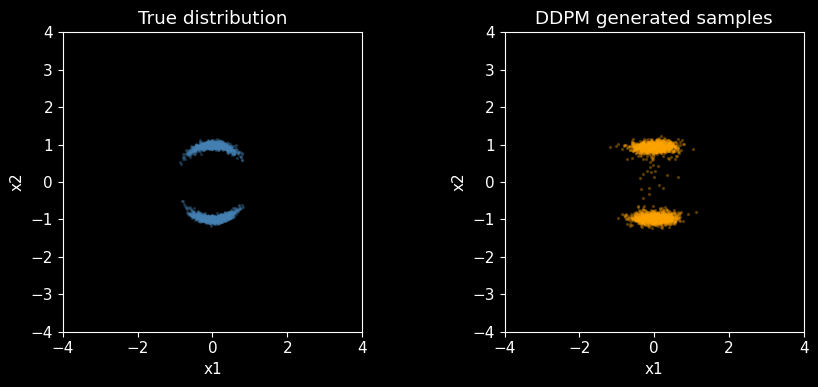

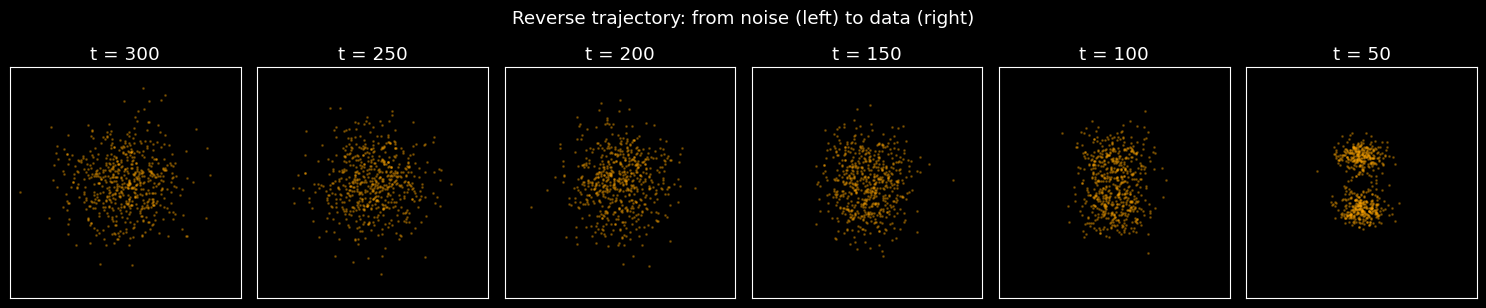

In [9]:
# --- True vs generated ---
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(x_data[:, 0], x_data[:, 1], s=2, alpha=0.25, c='steelblue')
axes[0].set_title('True distribution')
axes[1].scatter(np.array(samples[:, 0]), np.array(samples[:, 1]), s=2, alpha=0.25, c='orange')
axes[1].set_title('DDPM generated samples')
for ax in axes:
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

# --- Reverse trajectory: noise -> structure ---
steps_show = sorted(traj.keys(), reverse=True)[:6]
fig2, axes2 = plt.subplots(1, 6, figsize=(15, 3))
for ax, t in zip(axes2, steps_show):
    pts = traj[t][:600]
    ax.scatter(pts[:, 0], pts[:, 1], s=1, alpha=0.3, c='orange')
    ax.set_title(f't = {t}')
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Reverse trajectory: from noise (left) to data (right)', y=1.02)
plt.tight_layout(); plt.show()

## Deterministic Reverse Process

What happens if we drop the stochastic noise $\sqrt{\beta_t}\,\mathbf{z}$ from the reverse step and follow only the mean estimated noise correction?

$$\mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}}\!\left(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\,\hat{\boldsymbol{\varepsilon}}\right)$$

Each reverse step nudges a sample toward the network's best guess of the clean point, which for an ambiguous noisy input is an **average** over plausible clean points. The added noise normally shakes samples off this average; without it, every trajectory slides onto the averaged positions and the distribution collapses to the two cluster centres.

Running deterministic reverse diffusion...
Done.


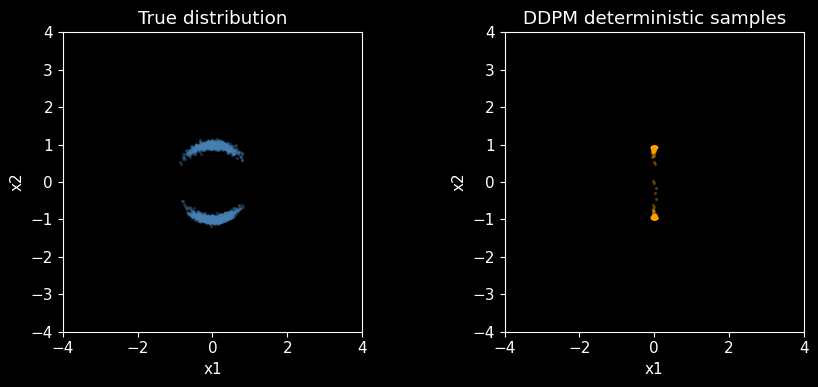

In [10]:
def ddpm_sample_deterministic(params, n_samples, key):
    '''Reverse chain without the stochastic noise term: x_{t-1} = mean(x_t, eps_hat).'''
    key, sk = random.split(key)
    x = random.normal(sk, (n_samples, 2))
    for t in range(T - 1, -1, -1):
        t_batch = jnp.full((n_samples,), t, dtype=jnp.int32)
        eps_hat = model.apply(params, x, t_batch)
        alpha_t, ab_t, beta_t = alphas[t], alpha_bars[t], betas[t]
        x = (x - beta_t / jnp.sqrt(1 - ab_t) * eps_hat) / jnp.sqrt(alpha_t)
    return x

print('Running deterministic reverse diffusion...')
key, sk = random.split(key)
samples_det = ddpm_sample_deterministic(params, 2000, sk)
print('Done.')

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(x_data[:, 0], x_data[:, 1], s=2, alpha=0.25, c='steelblue')
axes[0].set_title('True distribution')
axes[1].scatter(np.array(samples_det[:, 0]), np.array(samples_det[:, 1]), s=2, alpha=0.25, c='orange')
axes[1].set_title('DDPM deterministic samples')
for ax in axes:
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Summary

| Step | What it does | Key equation |
|------|-------------|---|
| **Forward** | Corrupt $\mathbf{x}_0 \to \mathbf{x}_T$ in $T$ steps | $\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\varepsilon}$ |
| **Training** | Predict added noise $\boldsymbol{\varepsilon}$ at random $t$ | $\mathcal{L} = \mathbb{E}\,\|\boldsymbol{\varepsilon} - \boldsymbol{\varepsilon}_\theta(\mathbf{x}_t, t)\|^2$ |
| **Sampling** | Iteratively remove predicted noise | $\mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}}\bigl(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\hat{\boldsymbol{\varepsilon}}\bigr) + \sqrt{\beta_t}\,\mathbf{z}$ |

### Extensions to Explore

- **DDIM** (Song et al. 2020) — deterministic sampler; 10–50$\times$ fewer network calls
- **Score SDEs** (Song et al. 2021) — continuous-time formulation; ODE sampler interpretation  
- **Classifier-free guidance** (Ho & Salimans 2021) — conditional generation without a separate classifier  
- **Latent diffusion / Stable Diffusion** (Rombach et al. 2022) — diffuse in a VAE latent space
